In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/FIzzCode862/AI_ML_Lab/refs/heads/main/KNN/Iris.csv"

df = pd.read_csv(url)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import label_binarize

In [ ]:
print(df.isnull().sum())


Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [ ]:
df = df.drop('Id', axis=1)

In [ ]:
encoder = LabelEncoder()

df['Species'] = encoder.fit_transform(df['Species'])

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


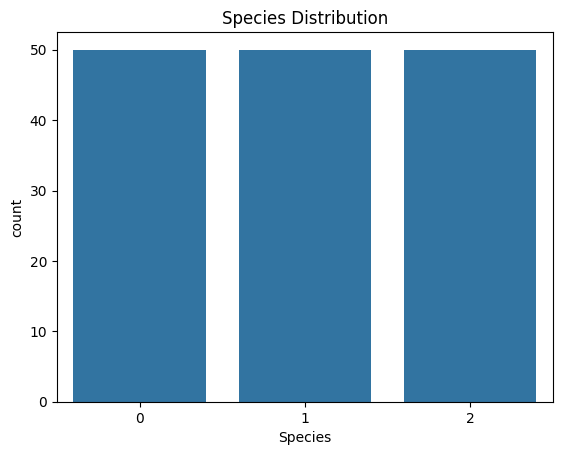

In [ ]:
sns.countplot(x='Species', data=df)

plt.title('Species Distribution')

plt.show()

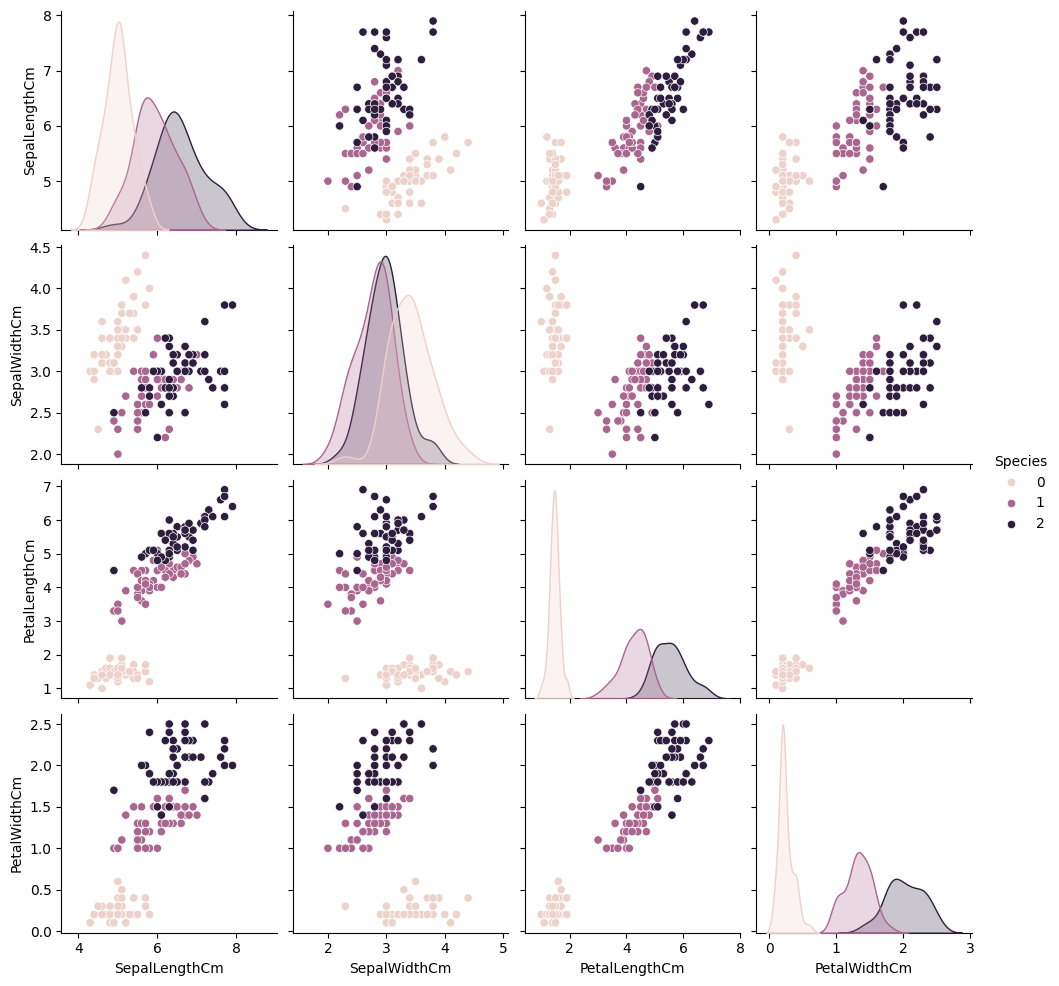

In [ ]:
sns.pairplot(df, hue='Species')

plt.show()

In [ ]:
X = df.drop('Species', axis=1)

y = df['Species']

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [ ]:
error_rate = []

for k in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    pred_k = knn.predict(X_test)

    error = np.mean(pred_k != y_test)

    error_rate.append(error)

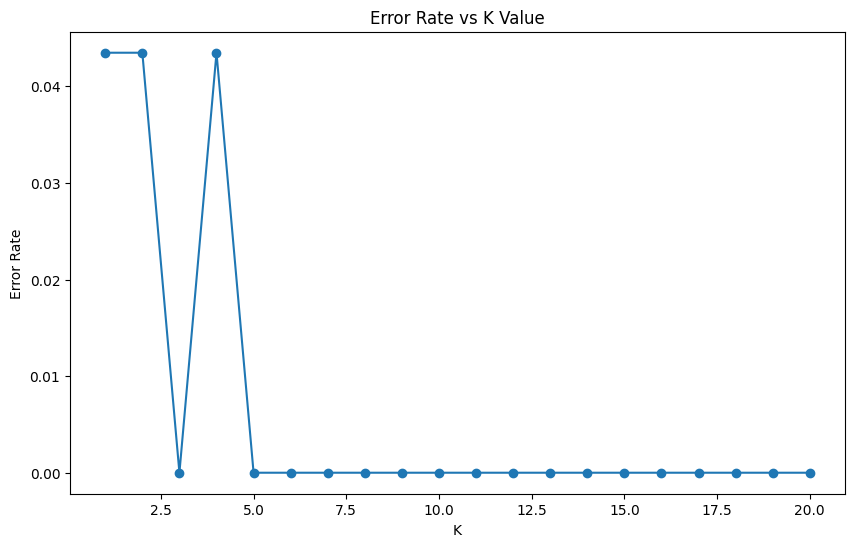

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1,21),
    error_rate,
    marker='o'
)

plt.title('Error Rate vs K Value')

plt.xlabel('K')

plt.ylabel('Error Rate')

plt.show()

In [ ]:
param_grid = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

In [ ]:
grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=5, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=5, we

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             verbose=2)

In [ ]:
print(grid.best_params_)

{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}


In [ ]:
best_knn = grid.best_estimator_

In [ ]:
y_pred = best_knn.predict(X_test)

y_prob = best_knn.predict_proba(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00         7

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



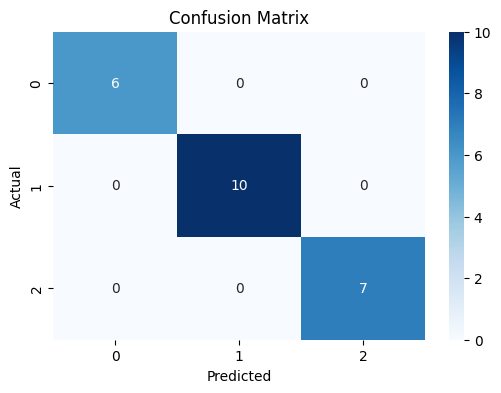

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

In [ ]:
y_test_bin = label_binarize(y_test, classes=[0,1,2])

auc_score = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class='ovr'
)

print("AUC Score:", auc_score)

AUC Score: 1.0


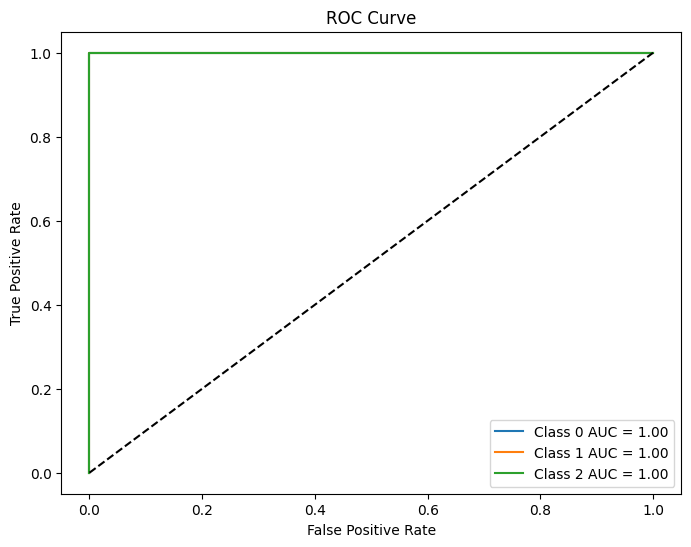

In [ ]:
n_classes = 3

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f'Class {i} AUC = {roc_auc[i]:.2f}'
    )

plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

In [ ]:
y_test_reset = y_test.reset_index(drop=True)

sample_results = pd.DataFrame({
    'Actual': y_test_reset,
    'Predicted': y_pred,
    'Probability': np.max(y_prob, axis=1)
})

sample_results.head(10)

,Actual,Predicted,Probability
0,0,0,1.000000
1,2,2,1.000000
2,2,2,0.666667
3,0,0,1.000000
4,2,2,0.666667
5,1,1,1.000000
6,1,1,1.000000
7,0,0,1.000000
8,1,1,0.666667
9,1,1,1.000000


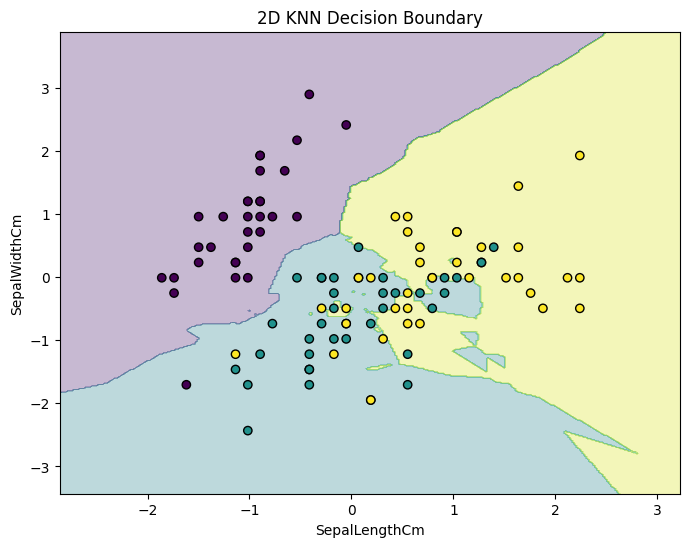

In [ ]:
from matplotlib.colors import ListedColormap

X_2d = X.iloc[:, :2]

y_2d = y

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y_2d,
    test_size=0.3,
    random_state=42
)

scaler_2d = StandardScaler()

X_train_2d = scaler_2d.fit_transform(X_train_2d)

X_test_2d = scaler_2d.transform(X_test_2d)

knn_2d = KNeighborsClassifier(n_neighbors=5)

knn_2d.fit(X_train_2d, y_train_2d)

x_min, x_max = X_train_2d[:,0].min()-1, X_train_2d[:,0].max()+1

y_min, y_max = X_train_2d[:,1].min()-1, X_train_2d[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_train_2d[:,0],
    X_train_2d[:,1],
    c=y_train_2d,
    edgecolor='k'
)

plt.xlabel(X.columns[0])

plt.ylabel(X.columns[1])

plt.title('2D KNN Decision Boundary')

plt.show()